# Superstore Retail Analytics — Exploration
### Sales, Profitability, Customer Behavior & Operational Performance
**Business Scenario:** A multinational retail company needs an automated analytical
solution to monitor sales, profitability, customer behavior, and operational
performance from its transactional data.

**Workflow:**
1. Data Import & Inspection
2. Memory Optimization and Fixing Types


## 1. Data Import & Inspection
#### What is the data that we will handle with it ?

We first need to *see* the data before touching it: how many rows/columns,
what types pandas inferred, whether anything looks obviously wrong (nulls,
duplicate order lines, inconsistent text). Only after this inspection pass do
we move on to fixing anything.

### A. Import the Laibraries and Dataset

**Loading the data.**
`pd.read_csv` reads the raw export with the first column (`Row ID`) used as
the DataFrame index. Right after loading, we also write an untouched Parquet
copy of the raw file (`Sample-Superstore2019.parquet`) — Parquet preserves
dtypes and is far faster to re-read than CSV, so it's a useful checkpoint even
before any cleaning happens.

In [7]:
# Core libraries for cleaning and exploring data
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import pyarrow
import seaborn as sns

# Read the Excel file into a DataFrame.
df_raw = pd.read_excel("Central_Superstore.xlsx")

df_raw.to_parquet("Central-Superstore.parquet")

**Never mutate the original load.**
`df = df_raw.copy()` gives us a working copy so that `df_raw` always stays
available as an unmodified fallback if we need to compare against the
original or start a cleaning step over.

In [8]:
#copy the data frame to a new variable to avoid changing the original data frame
df = df_raw.copy()
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7981,CA-2011-103800,2013-01-03,2013-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,740,CA-2011-112326,2013-01-04,2013-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,741,CA-2011-112326,2013-01-04,2013-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,742,CA-2011-112326,2013-01-04,2013-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,7661,CA-2011-105417,2013-01-07,2013-01-12,Standard Class,VS-21820,Vivek Sundaresam,Consumer,United States,Huntsville,...,77340,Central,FUR-FU-10004864,Furniture,Furnishings,"Howard Miller 14-1/2"" Diameter Chrome Round Wa...",76.728,3,0.6,-53.7096


### B. Inspect and Describe The Data

**Shape and a quick visual sanity check.**
`.shape` tells us row/column count at a glance. Looking at `.tail(3)` (rather
than only `.head()`) helps catch issues that only show up later in the file,
such as a different formatting convention appearing near the end of an export.

In [9]:
# Shape: (number of rows, number of columns)
print("Shape:", df.shape)

# last rows — sanity check that data looks like what we expect
df.tail(3)

Shape: (2323, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2320,7486,CA-2014-135111,2016-12-28,2017-01-02,Standard Class,CS-12400,Christopher Schild,Home Office,United States,Fargo,...,58103,Central,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,25.9,5,0.0,12.691
2321,4240,CA-2014-158673,2016-12-29,2017-01-04,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Grand Rapids,...,49505,Central,OFF-PA-10000994,Office Supplies,Paper,Xerox 1915,209.7,2,0.0,100.656
2322,646,CA-2014-126221,2016-12-30,2017-01-05,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,...,47201,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.3,2,0.0,56.511


**Column names.**
Printing the raw column list confirms exact spelling/casing (e.g. `Ship Mode`
vs `ShipMode`) before we reference these names anywhere else in the notebook —
a mismatch here is one of the most common sources of `KeyError`s downstream.
`Categorical_columns` is initialized here as an empty list and gets populated
properly later in Section 3C.

In [10]:
# Column names
print(f"Column names: {df.columns.tolist()}")
Categorical_columns = []

Column names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


**`.info()` — the fastest first checkpoint.**
This single call reports, for every column: its inferred dtype, how many
non-null values it has (so missing data is visible immediately), and total
memory footprint. It's the cheapest way to get an overview of *both* data
quality and data cost in one shot.

In [11]:
# .info() gives dtypes + non-null counts + memory usage all at once
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2323 entries, 0 to 2322
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2323 non-null   int64         
 1   Order ID       2323 non-null   str           
 2   Order Date     2323 non-null   datetime64[us]
 3   Ship Date      2323 non-null   datetime64[us]
 4   Ship Mode      2323 non-null   str           
 5   Customer ID    2323 non-null   str           
 6   Customer Name  2323 non-null   str           
 7   Segment        2323 non-null   str           
 8   Country        2323 non-null   str           
 9   City           2323 non-null   str           
 10  State          2323 non-null   str           
 11  Postal Code    2323 non-null   int64         
 12  Region         2323 non-null   str           
 13  Product ID     2323 non-null   str           
 14  Category       2323 non-null   str           
 15  Sub-Category   2323 non-null   s

**Numeric summary statistics.**
`.describe()` reports count, mean, std, min, quartiles, and max for every
numeric column. Watch in particular for:
- `Profit` having a **negative minimum** — orders sold at a loss (expected,
  not an error, in retail data).
- `Discount` bounded between 0 and 1 — anything outside that range would flag
  a data-entry problem.
- `Postal Code` showing up here even though it's really a categorical/ID
  field, not a quantity — a sign it should be cast to `str`, which we do in
  Section 2B.

In [12]:
# Summary stats for numeric columns: Sales, Quantity, Discount, Profit, Postal Code, Row ID...
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,2323.000000,2323,2323,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000
mean,5030.547998,2015-04-29 19:22:17.408523,2015-05-03 20:45:58.501937,65340.572536,215.772661,3.779595,0.240353,17.092709
min,15.000000,2013-01-03 00:00:00,2013-01-07 00:00:00,46060.000000,0.444000,1.000000,0.000000,-3701.892800
25%,2564.500000,2014-04-29 00:00:00,2014-05-05 00:00:00,55125.000000,14.620000,2.000000,0.000000,-5.664300
50%,5029.000000,2015-07-23 00:00:00,2015-07-27 00:00:00,65203.000000,45.980000,3.000000,0.200000,5.184000
75%,7612.500000,2016-05-09 12:00:00,2016-05-13 00:00:00,77041.000000,200.012000,5.000000,0.300000,22.456200
max,9984.000000,2016-12-30 00:00:00,2017-01-05 00:00:00,79907.000000,17499.950000,14.000000,0.800000,8399.976000
std,2923.638538,NaN,NaN,11427.949045,632.779010,2.160561,0.265433,291.487465


**Categorical/text summary statistics.**
`describe(include="str")` mirrors the same idea for text columns: count,
number of unique values, the most frequent value, and its frequency. This is
a fast way to eyeball cardinality (e.g. how many distinct `Customer Name`
values exist) and to catch a dominant category before doing any grouping.

In [13]:
# Summary stats for text/categorical columns
df.describe(include="str")

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,2323,2323,2323,2323,2323,2323,2323,2323,2323,2323,2323,2323,2323
unique,1175,4,629,629,3,1,181,13,1,1310,3,17,1295
top,CA-2013-105732,Standard Class,MA-17560,Matt Abelman,Consumer,United States,Houston,Texas,Central,OFF-BI-10004364,Office Supplies,Binders,Staple envelope
freq,10,1439,17,17,1212,2323,377,985,2323,7,1422,366,13


## 2. Memory Optimization
#### What the cost of storing this data and How to reduce this cost?

Before optimizing anything, we need a baseline: how much memory does the
DataFrame actually consume *right now*, column by column? Without this
number, "we reduced memory usage" has nothing to be measured against.

### A. Discover Memory

**`memory_usage(deep=True)` — why `deep=True` matters.**
For object/string columns, pandas stores pointers, not raw bytes, so a
shallow memory count is misleading. `deep=True` walks into the actual string
data and reports true memory consumption per column — this is the number we
compare against after the dtype fixes below.

In [14]:
df.memory_usage(deep=True)

Index               132
Row ID            18584
Order ID          51106
Order Date        18584
Ship Date         18584
Ship Mode         48559
Customer ID       37168
Customer Name     48766
Segment           39155
Country           48783
City              36957
State             34171
Postal Code       18584
Region            34845
Product ID        53429
Category          48443
Sub-Category      35303
Product Name     105358
Sales             18584
Quantity          18584
Discount          18584
Profit            18584
dtype: int64

### B. Fix The Datatypes 

**Fixing dtypes: dates and postal codes.**
Two separate problems are being solved here:
- `Order Date` / `Ship Date` arrive as plain text; `pd.to_datetime` converts
  them to real `datetime64[ns]` values, which is what makes date arithmetic
  (e.g. shipping duration), `.dt` accessors, and time-based grouping possible
  later.
- `Postal Code` arrives as a *float* (because of the missing values pandas
  saw on load), which is wrong for an identifier that should never be
  averaged or summed. Casting it to `str` fixes the semantic type — though
  note this happens *before* the missing-value fix in Section 3A, so at this
  point any null postal codes are still floating around as the literal string
  `"nan"`.

In [15]:
# Convert the two date columns from text to real datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Postal Code"] = df["Postal Code"].astype("str")

# Check the dtypes of the two date columns to confirm they are now datetime64[ns]
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)
print(df["Postal Code"].dtype)

datetime64[us]
datetime64[us]
str


**Fixing dtypes: low-cardinality text → `category`.**
Columns like `Segment`, `Region`, `Ship Mode`, and `Category` only take on a
handful of distinct values across ~10,000 rows. Storing them as pandas
`category` dtype keeps one small integer code per row plus a single shared
lookup table of the distinct labels, instead of repeating the full string
on every row — the single biggest lever for memory reduction available here.

In [16]:
# Convert low-cardinality text columns to the 'category' dtype (memory + speed win)
for col in ["Segment", "Region", "Ship Mode", "Category"]:
    df[col] = df[col].astype("category")

df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode              category
Customer ID                 str
Customer Name               str
Segment                category
Country                     str
City                        str
State                       str
Postal Code                 str
Region                 category
Product ID                  str
Category               category
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Now that the date columns and the low-cardinality text columns have been
re-typed, we re-run the same memory check from Section 2A to confirm the
optimization actually worked, rather than just assuming it did.

### Cofirm Memory Reduction

**Confirming the reduction.**
Comparing this `df.info(memory_usage='deep')` output against the Section 2A
baseline should show a visibly smaller total memory footprint — the
`category` conversions in particular should meaningfully shrink `Segment`,
`Region`, `Ship Mode`, and `Category`.

In [17]:
print(df.info(memory_usage='deep'))

<class 'pandas.DataFrame'>
RangeIndex: 2323 entries, 0 to 2322
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2323 non-null   int64         
 1   Order ID       2323 non-null   str           
 2   Order Date     2323 non-null   datetime64[us]
 3   Ship Date      2323 non-null   datetime64[us]
 4   Ship Mode      2323 non-null   category      
 5   Customer ID    2323 non-null   str           
 6   Customer Name  2323 non-null   str           
 7   Segment        2323 non-null   category      
 8   Country        2323 non-null   str           
 9   City           2323 non-null   str           
 10  State          2323 non-null   str           
 11  Postal Code    2323 non-null   str           
 12  Region         2323 non-null   category      
 13  Product ID     2323 non-null   str           
 14  Category       2323 non-null   category      
 15  Sub-Category   2323 non-null   s

### A. Detect Missing Data

**Counting nulls per column.**
`isnull().sum()` gives the missing-value count column by column. In this
dataset, `Postal Code` is the only column with nulls — everything else is
fully populated.

In [18]:
# Count missing values per column
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

**Investigating the missing `Postal Code` values.**
Rather than filling blindly, we look at the actual `City`/`State` for the
affected rows. If the missing postal codes cluster around one specific
city, that's a strong signal for what value should be imputed, instead of a
generic placeholder or an outright drop.

### B. Detect Duplicates

**Two different duplicate checks.**
- `duplicated()` with no arguments checks for **exact, full-row** duplicates
  — every single column matching. There are none.
- `duplicated(subset=["Order ID", "Product ID"])` checks something more
  business-meaningful: the *same product appearing more than once within the
  same order*. This can be entirely legitimate (e.g. two rows for the same
  product bought on different discount terms), so it needs a closer look
  rather than an automatic drop — which is exactly what the next two cells do.

In [21]:
# Exact full-row duplicates
print("Exact duplicate rows:", df_cleaned.duplicated().sum())

# Duplicates on a more meaningful subset: same order line for the same product
print("Duplicate Order ID + Product ID pairs :", df_cleaned.duplicated(subset=["Order ID", "Product ID"]).sum())

Exact duplicate rows: 0
Duplicate Order ID + Product ID pairs : 0


**Inspecting subset-duplicates on the pre-imputation `df`.**
Pulling up the actual rows behind the `Order ID` + `Product ID` duplicate
flag (sorted so matching pairs sit next to each other) lets us confirm
whether these are true duplicate entries or legitimately separate line items
(different quantities, prices, or discounts) before deciding not to drop
them.

"Dirty" here means *inconsistent formatting* rather than missing data:
stray whitespace, inconsistent casing, or unexpected category variants that
would cause the same real-world value to be counted as two different groups
in any `groupby()`.

### C. Detect Dirty Data

**Splitting columns by cardinality.**
Any column with fewer than 5 distinct values gets bucketed as
`Categorical_columns` (e.g. `Ship Mode`, `Segment`) — these are cheap to
eyeball in full. Everything else (`others`) is high-cardinality (names, IDs,
product titles) and isn't a good candidate for a full `.unique()` printout.

In [24]:
Categorical_columns = []
others = []
for col in df_cleaned.columns:
    if df_cleaned[col].nunique() < 5:
        Categorical_columns.append(col) 
    else:
        others.append(col)

print(f"Categorical columns ({len(Categorical_columns)} columns): {Categorical_columns}")
print(f"Other columns ({len(others)} columns): {others}")

Categorical columns (5 columns): ['Ship Mode', 'Segment', 'Country', 'Region', 'Category']
Other columns (16 columns): ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name', 'City', 'State', 'Postal Code', 'Product ID', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


**Whitespace cleanup and category-value audit.**
Every object/text column gets `.str.strip()` applied to remove leading/
trailing whitespace that wouldn't be visible on a normal print but would
still split identical values into separate groups. Then, for just the
low-cardinality `Categorical_columns` identified above, we print every
distinct value that actually appears — the fast way to catch a stray
`"consumer "` vs `"Consumer"`-style inconsistency.

In [25]:
# Check every key categorical column for stray variants (casing, whitespace, typos)
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].str.strip()

    
for col in Categorical_columns:
    print(col, "->", df_cleaned[col].unique())

Ship Mode -> ['Standard Class', 'First Class', 'Second Class', 'Same Day']
Categories (4, str): ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Segment -> ['Consumer', 'Home Office', 'Corporate']
Categories (3, str): ['Consumer', 'Corporate', 'Home Office']
Country -> <ArrowStringArray>
['United States']
Length: 1, dtype: str
Region -> ['Central']
Categories (1, str): ['Central']
Category -> ['Office Supplies', 'Furniture', 'Technology']
Categories (3, str): ['Furniture', 'Office Supplies', 'Technology']


C:\Users\MZ\AppData\Local\Temp\ipykernel_12092\2081630390.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include='object').columns


Outliers get a different treatment from missing/duplicate data: an extreme
`Sales` or `Profit` value isn't necessarily *wrong* — a single bulk order or
a heavily discounted loss-leader is a real business event. The goal here is
to **detect and understand** extreme values, not to blindly strip them out.

### D. Detect Outliers

**Range sanity checks first.**
Before running any statistical outlier detection, two quick domain checks:
`Discount` should always fall within `[0, 1]` (it does), and negative
`Profit` values are counted — these are expected in retail data (heavily
discounted or bulk orders can sell at a loss) rather than a sign of corrupted
data.

In [26]:
# Range sanity check: Discount should never be negative or above 1 (100%)
print("Discount min/max:", df_cleaned["Discount"].min(), df_cleaned["Discount"].max())

# Negative profit is common in this dataset -- a real business signal, not an error
print("Orders sold at a loss:", (df_cleaned["Profit"] < 0).sum())

Discount min/max: 0.0 0.8
Orders sold at a loss: 741


**Average Sales per Segment.**
Grouping by `Segment` and taking the mean `Sales` gives a first look at
whether outlier behavior might differ meaningfully across segments before we
split the data three ways in the next cell.

In [27]:
# Segment Sales by Segment
segment_sales = df_cleaned.groupby("Segment")["Sales"].mean()
print(segment_sales)

Segment
Consumer       207.946728
Corporate      234.763466
Home Office    208.248046
Name: Sales, dtype: float64


**Splitting the data by segment.**
`Consumer_Sales`, `Corporate_Sales`, and `Home_Office_Sales` isolate each
`Segment` into its own DataFrame slice, so outliers can be examined
per-segment rather than pooled — a segment-specific bulk order shouldn't be
judged against the overall population's spread.

In [28]:
Consumer_Sales = df_cleaned[df_cleaned["Segment"] == "Consumer"]
Corporate_Sales = df_cleaned[df_cleaned["Segment"] == "Corporate"]
Home_Office_Sales = df_cleaned[df_cleaned["Segment"] == "Home Office"]
print(Consumer_Sales.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0    7981  CA-2011-103800 2013-01-03 2013-01-07  Standard Class    DP-13000   
4    7661  CA-2011-105417 2013-01-07 2013-01-12  Standard Class    VS-21820   
5    7662  CA-2011-105417 2013-01-07 2013-01-12  Standard Class    VS-21820   
6     593  CA-2011-135405 2013-01-09 2013-01-13  Standard Class    MS-17830   
7     594  CA-2011-135405 2013-01-09 2013-01-13  Standard Class    MS-17830   

      Customer Name   Segment        Country        City  ... Postal Code  \
0     Darren Powers  Consumer  United States     Houston  ...       77095   
4  Vivek Sundaresam  Consumer  United States  Huntsville  ...       77340   
5  Vivek Sundaresam  Consumer  United States  Huntsville  ...       77340   
6     Melanie Seite  Consumer  United States      Laredo  ...       78041   
7     Melanie Seite  Consumer  United States      Laredo  ...       78041   

    Region       Product ID         Category Sub-Category  \
0

**Visual outlier check — boxplots by segment.**
A boxplot puts the median, interquartile range, and whisker bounds on
screen at once; any point plotted beyond the whiskers is a candidate
outlier. Plotting the three segments side by side (rather than one combined
boxplot) makes it easy to see whether one segment has a meaningfully
different Sales spread from the others.

C:\Users\MZ\AppData\Local\Temp\ipykernel_12092\2648862987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x=Consumer_Sales["Sales"], palette="Set2")
C:\Users\MZ\AppData\Local\Temp\ipykernel_12092\2648862987.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x=Corporate_Sales["Sales"], palette="Set2")
C:\Users\MZ\AppData\Local\Temp\ipykernel_12092\2648862987.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x=Home_Office_Sales["Sales"], palette="Set2")


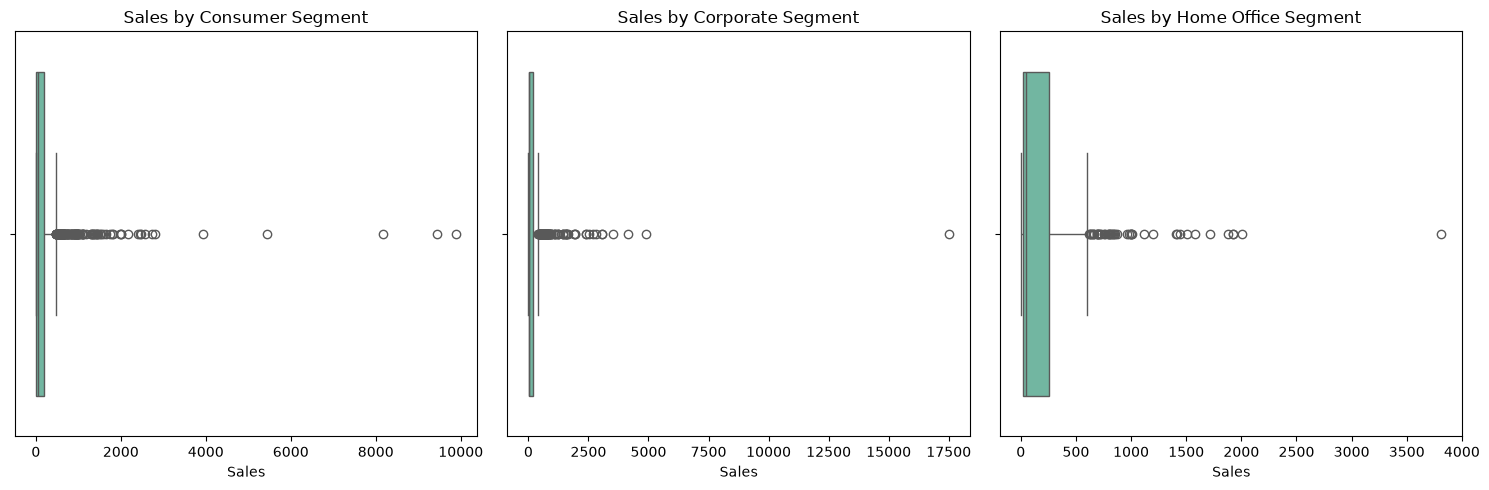

In [29]:
# Visual check for outliers in Sales segments using a boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=Consumer_Sales["Sales"], palette="Set2")
axes[0].set_title("Sales by Consumer Segment")

sns.boxplot(ax=axes[1], x=Corporate_Sales["Sales"], palette="Set2")
axes[1].set_title("Sales by Corporate Segment")

sns.boxplot(ax=axes[2], x=Home_Office_Sales["Sales"], palette="Set2")
axes[2].set_title("Sales by Home Office Segment")
plt.tight_layout()


**Quantifying outliers with the IQR rule.**
`find_outliers_iqr()` formalizes what the boxplots showed visually: any value
more than `1.5 × IQR` below Q1 or above Q3 is flagged as a statistical
outlier. The function returns the bounds used, the outlier count, and a
preview of the flagged rows — run separately for each segment so the bounds
are computed on each segment's own distribution rather than the combined
dataset. Note the function is intentionally **detection-only** here: it
reports outliers without dropping or capping them, keeping that decision
explicit and separate from the detection step.

In [30]:
# IQR method: flag numeric outliers beyond 1.5x the interquartile range
def find_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    is_outlier = (data[column] < lower_bound) | (data[column] > upper_bound)
    outliers = data[is_outlier]
    n_outliers = is_outlier.sum()

    target_cols = [
        "Order_ID",
        "Customer_ID",
        "Sales",
        "Quantity",
        "Segment",
        "Profit",
    ]

    available_cols = [col for col in target_cols if col in data.columns]
    cols_to_show = available_cols if available_cols else data.columns

    return (
        str(data.shape[0]) + " rows",
        "lower bound: " + str(lower_bound),
        "upper bound: " + str(upper_bound),
        "number of outliers: " + str(n_outliers),
        outliers[cols_to_show].head(),
    )


print("=== Consumer Segment Outliers ===")
display(find_outliers_iqr(Consumer_Sales, "Sales"))

print("\n=== Corporate Segment Outliers ===")
display(find_outliers_iqr(Corporate_Sales, "Sales"))

print("\n=== Home Office Segment Outliers ===")
display(find_outliers_iqr(Home_Office_Sales, "Sales"))


=== Consumer Segment Outliers ===


('1212 rows',
 'lower bound: -261.54249999999996',
 'upper bound: 473.26949999999994',
 'number of outliers: 131',
         Sales  Quantity   Segment    Profit
 62   1184.720         4  Consumer  106.6248
 63    890.841         3  Consumer -152.7156
 79    689.820         6  Consumer   20.6946
 86    744.100         5  Consumer  -95.6700
 149   647.840         8  Consumer   32.3920)


=== Corporate Segment Outliers ===


('673 rows',
 'lower bound: -224.03200000000007',
 'upper bound: 412.0000000000001',
 'number of outliers: 89',
         Sales  Quantity    Segment    Profit
 101  1212.960         8  Corporate  -69.3120
 123   719.976         3  Corporate  134.9955
 143   491.550         5  Corporate  240.8595
 146   797.944         4  Corporate  -56.9960
 187   657.930         5  Corporate  -93.9900)


=== Home Office Segment Outliers ===


('438 rows',
 'lower bound: -342.2135',
 'upper bound: 612.8625',
 'number of outliers: 45',
         Sales  Quantity      Segment    Profit
 40    634.116         6  Home Office -172.1172
 80    758.352         6  Home Office  265.4232
 124  2001.860         7  Home Office  580.5394
 127  1503.250         5  Home Office  496.0725
 184   981.372         2  Home Office -140.1960)

**Extending the same check to `Quantity`.**
The same detect-before-you-touch approach is applied to `Quantity`: a boxplot
to see the spread visually, plus an explicit min/max range check, to confirm
whether `Quantity` shows the same kind of extreme-but-legitimate values seen
in `Sales` and `Profit`.

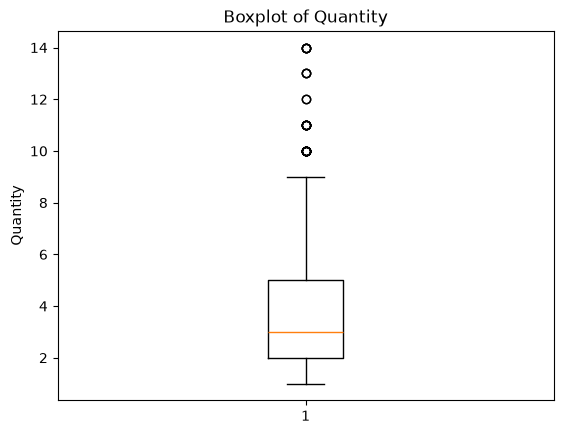

Quantity range: [1, 14]


In [31]:
# TODO 2: boxplot for Quantity
plt.boxplot(df_cleaned["Quantity"])
plt.title("Boxplot of Quantity")
plt.ylabel("Quantity")
plt.show()

# TODO 3: range sanity check on Quantity (min/max)
print(f"Quantity range: [{df_cleaned['Quantity'].min()}, {df_cleaned['Quantity'].max()}]")

With missing values imputed, duplicates investigated, text standardized, and
outliers characterized (without being blindly removed), `df_cleaned` is now
in a trustworthy state. The last step is to persist it so downstream
notebooks (feature engineering, KPI generation, visualization) don't need to
repeat any of this work.